# mjo_cross_plot

### Example NCL Script and Output

- mjo_cross.ncl
- mjo_output/mjo_cross_output.txt

### Example Plot fom `mjo_cross.ncl`

- mjo_output/mjo_cross.png

<center>
<img src="mjo_output/mjo_cross.png" width="400" height="600">
</center>

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import xarray as xr
import numpy as np

#https://github.com/NCAR/ncl/blob/8f9e9476281cc6f6d9d12eaa78729c7003ca24b7/ni/src/examples/gsun/diagnostics_cam.ncl#L3415

In [2]:
# collect NCL data from mjo_output
mjo_cross_data = np.loadtxt("mjo_output/mjo_cross_output.txt", skiprows=26)
# [var | 16] x [freq | 129] x [wave | 289]
mjo_cross_data = mjo_cross_data.reshape(16, 129, 289) 
STC = xr.DataArray(mjo_cross_data, dims=["var", "freq", "wavenumber"])
STC

<xarray.DataArray (var: 16, freq: 129, wavenumber: 289)> Size: 5MB
array([[[ 6.37317325e-05,  4.52805602e-05,  2.48578879e-05, ...,
          2.48578879e-05,  4.52805602e-05,  6.37317325e-05],
        [ 7.17503831e-05,  3.74304080e-05,  3.85263494e-05, ...,
          2.39251710e-05,  4.01914535e-05,  7.17503831e-05],
        [ 2.22001819e-05,  2.56295398e-05,  2.17989571e-05, ...,
          1.56655483e-05,  1.82418340e-05,  2.22001819e-05],
        ...,
        [ 9.73201462e-06,  9.65238049e-06,  9.35838465e-06, ...,
          1.01098820e-05,  1.04302409e-05,  9.73201462e-06],
        [ 1.13301551e-05,  9.28979478e-06,  1.11075967e-05, ...,
          1.00174663e-05,  1.04329004e-05,  1.13301551e-05],
        [ 8.77065288e-06,  1.03120924e-05,  1.08110414e-05, ...,
          1.08110414e-05,  1.03120924e-05,  8.77065288e-06]],

       [[ 4.43781980e-05,  4.45263580e-05,  2.90879385e-05, ...,
          2.90879385e-05,  4.45263580e-05,  4.43781980e-05],
        [ 7.25274863e-05,  3.96777662e-05,  2.30753421e-05, ...,
          2.04378557e-05,  4.75222725e-05,  7.25274863e-05],
        [ 4.33309048e-05,  2.26302995e-05,  1.65199271e-05, ...,
          1.92639790e-05,  2.15642943e-05,  4.33309048e-05],
...
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  9.78497392e-01,  0.00000000e+00, ...,
          0.00000000e+00,  9.67152290e-01,  0.00000000e+00]],

       [[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00]]],
      shape=(16, 129, 289))
Dimensions without coordinates: var, freq, wavenumber

In [3]:
# n = 8
# ( 8,:,:)  -  symmetric coherence-squared spectrum
c2s = mjo_cross_data[8] #STC.isel(var=8, wavenumber=slice(-15, 15))
c2s[0,:] = np.nan
c2s = np.where(c2s < 0.05, np.nan, c2s)
c2s

array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [       nan,        nan, 0.05043082, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan, 0.06392697,        nan, ...,        nan, 0.07906254,
               nan]], shape=(129, 289))

In [4]:
# n = 12
# (12,:,:)  -  symmetric component-1 phase spectrum
phs1 = mjo_cross_data[12]
phs1[0,:] = np.nan
phs1 = np.where(c2s < 0.05, np.nan, phs1)
phs1

array([[        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.37899029, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        , -0.20625919,  0.        , ...,  0.        ,
         0.25419765,  0.        ]], shape=(129, 289))

In [5]:
# n = 14
# (14,:,:)  -  symmetric component-2 phase spectrum
phs2 = mjo_cross_data[14]
phs2[0,:] = np.nan
phs2 = np.where(c2s < 0.05, np.nan, phs2)
phs2

array([[        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        , -0.92540065, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.97849739,  0.        , ...,  0.        ,
         0.96715229,  0.        ]], shape=(129, 289))

In [6]:
masked_phs1 = np.ma.masked_equal(phs1, 0)
masked_phs2 = np.ma.masked_equal(phs2, 0)
                               
scl_sqrt = np.sqrt(1/(masked_phs1**2 + masked_phs2**2)) # L3564 - https://github.com/NCAR/ncl/blob/8f9e9476281cc6f6d9d12eaa78729c7003ca24b7/ni/src/examples/gsun/diagnostics_cam.ncl#L3564
scl_one = scl_sqrt.data

phs1 = scl_one * phs1
phs2 = scl_one * phs2

In [7]:
# asymmetric data

In [8]:
# n = 9
# ( 9,:,:)  -  asymmetric coherence-squared spectrum
c2a = mjo_cross_data[9] #STC.isel(var=9, wavenumber=slice(-15, 15))
c2a[0,:] = np.nan
c2a = np.where(c2a < 0.05, np.nan, c2a)
c2a

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(129, 289))

In [9]:
# n = 13
# (13,:,:)  -  asymmetric component-1 phase spectrum
# asymmetric phase-1
pha1 = mjo_cross_data[13] #STC.isel(var=13, wavenumber=slice(-15, 15))
pha1[0,:] = np.nan
pha1

array([[nan, nan, nan, ..., nan, nan, nan],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]], shape=(129, 289))

In [10]:
# n = 15
# (15,:,:)  -  asymmetric component-2 phase spectrum
# asymmetric phase-2
pha2 = mjo_cross_data[15] #STC.isel(var=15, wavenumber=slice(-15, 15))
pha2[0,:] = np.nan
pha2 = np.where(c2a < 0.05, np.nan, pha2)
pha2

array([[nan, nan, nan, ..., nan, nan, nan],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]], shape=(129, 289))

In [11]:
# from mjo_cross_output.txt
prob_coh2 = [0.007943451, 0.02954906, 0.1019666, 0.1846326, 0.3290648, 0.8042979]
prob_days = [80, 20, 10, 5, 3, 1]
freq = [0, 0.5]

ValueError: x and y must have same first dimension, but have shapes (2,) and (129, 289)

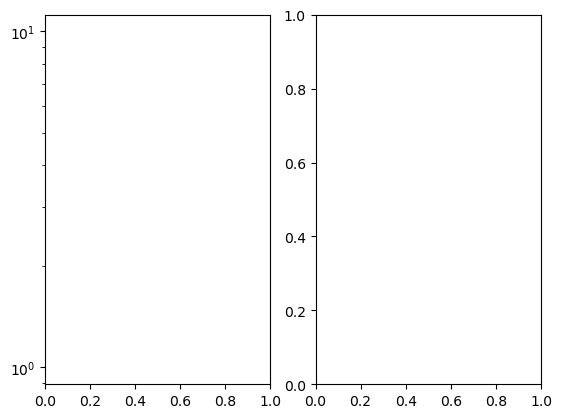

In [13]:
max_wave_plot = 15 # min/max wavenumber to plot on the x-axis (default = 15)

font_size = 7
major_length = 8
minor_length = 4
title_pad = 10

fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True)

#TODO: Add dispersion curve: https://github.com/NCAR/ncl/blob/8f9e9476281cc6f6d9d12eaa78729c7003ca24b7/ni/src/examples/gsun/diagnostics_cam.ncl#L3490

#ax1.semilogy(freqs, cps_mag)
#ax1.contour(freq, wavenumbers, c2s)
ax1.set_xlim(-max_wave_plot, max_wave_plot)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(5))
#ax1.set_ylim(freq[0], freq[1])
ax1.set_title("Coh^2: Symmetric", loc="left", fontsize=font_size, pad=title_pad)
ax1.set_title("10%=0.10, 5%-0.33", loc="right", fontsize=font_size, pad=title_pad)
ax1.tick_params(which="major", length=major_length, top=True, right=True, bottom=True, left=True)
ax1.tick_params(which="minor", length=minor_length, top=True, right=True)
ax1.minorticks_on()
ax1.axvline(x=0, color="grey", linestyle="--", alpha=0.5)
for i, y_line in enumerate(prob_coh2):
    if y_line < freq[1]: # filter out options out of the range of freq
        ax1.axhline(y=y_line, color="grey", linestyle="--", alpha=0.5)
        # add days label with white box around text
        ax1.text(x=-max_wave_plot+0.5, y=y_line, s=f"{prob_days[i]} days",
                ha="left", va="center", fontsize=font_size,
                bbox=dict(facecolor="white", edgecolor="white", boxstyle='round'))

#ax2.plot(freqs, cps_phase)
ax2.set_xlim(-max_wave_plot, max_wave_plot)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(5))
#ax2.set_ylim(freq[0], freq[1])
ax2.set_title("Coh^2: Asymmetric", loc="left", fontsize=font_size, pad=title_pad)
ax2.set_title("10%=0.10, 5%-0.33", loc="right", fontsize=font_size, pad=title_pad)
ax2.tick_params(which="major", length=major_length, top=True, right=True, bottom=True, left=True)
ax2.tick_params(which="minor", length=minor_length, top=True, right=True)
ax2.minorticks_on()
ax2.axvline(x=0, color="grey", linestyle="--", alpha=0.5)
for i, y_line in enumerate(prob_coh2):
    if y_line < freq[1]: # filter out options out of the range of freq
        ax2.axhline(y=y_line, color="grey", linestyle="--", alpha=0.5)
        # add days label with white box around text
        ax2.text(x=-max_wave_plot+0.5, y=y_line, s=f"{prob_days[i]} days",
                ha="left", va="center", fontsize=font_size,
                bbox=dict(facecolor="white", edgecolor="white", boxstyle='round'))

plt.suptitle("mjo_cross Example: -15S-15N")
plt.tight_layout()
plt.show()